In [1]:
from google.colab import files

uploaded = files.upload()

Saving AcneDataset.zip to AcneDataset.zip


In [3]:
import zipfile

with zipfile.ZipFile(
"AcneDataset.zip",
"r"
) as zip_ref:

    zip_ref.extractall(
        "/content/acne_dataset"
    )

print("Done")

Done


In [4]:
import os

for root, dirs, files in os.walk(
"/content/acne_dataset"
):

    print(
        root,
        len(files)
    )

/content/acne_dataset 0
/content/acne_dataset/AcneDataset 0
/content/acne_dataset/AcneDataset/test 1
/content/acne_dataset/AcneDataset/test/Pustules 205
/content/acne_dataset/AcneDataset/test/Blackheads 265
/content/acne_dataset/AcneDataset/test/Cyst 189
/content/acne_dataset/AcneDataset/test/Papules 202
/content/acne_dataset/AcneDataset/test/Whiteheads 57
/content/acne_dataset/AcneDataset/valid 1
/content/acne_dataset/AcneDataset/valid/Pustules 217
/content/acne_dataset/AcneDataset/valid/Blackheads 240
/content/acne_dataset/AcneDataset/valid/Cyst 206
/content/acne_dataset/AcneDataset/valid/Papules 209
/content/acne_dataset/AcneDataset/valid/Whiteheads 49
/content/acne_dataset/AcneDataset/train 1
/content/acne_dataset/AcneDataset/train/Pustules 584
/content/acne_dataset/AcneDataset/train/Blackheads 735
/content/acne_dataset/AcneDataset/train/Cyst 645
/content/acne_dataset/AcneDataset/train/Papules 621
/content/acne_dataset/AcneDataset/train/Whiteheads 193


In [5]:
import os
import shutil

source="/content/acne_dataset/AcneDataset"

target="/content/acne_final"

classes=[
"Cyst",
"Papules",
"Pustules"
]

splits=[
"train",
"valid",
"test"
]

os.makedirs(
target,
exist_ok=True
)

for split in splits:

    for cls in classes:

        src=os.path.join(
            source,
            split,
            cls
        )

        dst=os.path.join(
            target,
            split,
            cls
        )

        os.makedirs(
            os.path.dirname(dst),
            exist_ok=True
        )

        shutil.copytree(
            src,
            dst
        )

print("Filtering selesai")

Filtering selesai


In [6]:
summary=[]

for split in splits:

    for cls in classes:

        folder=os.path.join(
            target,
            split,
            cls
        )

        summary.append([
            split,
            cls,
            len(
                os.listdir(
                    folder
                )
            )
        ])

import pandas as pd

summary=pd.DataFrame(
summary,
columns=[
"Split",
"Class",
"Count"
]
)

summary

,Split,Class,Count
0,train,Cyst,645
1,train,Papules,621
2,train,Pustules,584
3,valid,Cyst,206
4,valid,Papules,209
5,valid,Pustules,217
6,test,Cyst,189
7,test,Papules,202
8,test,Pustules,205


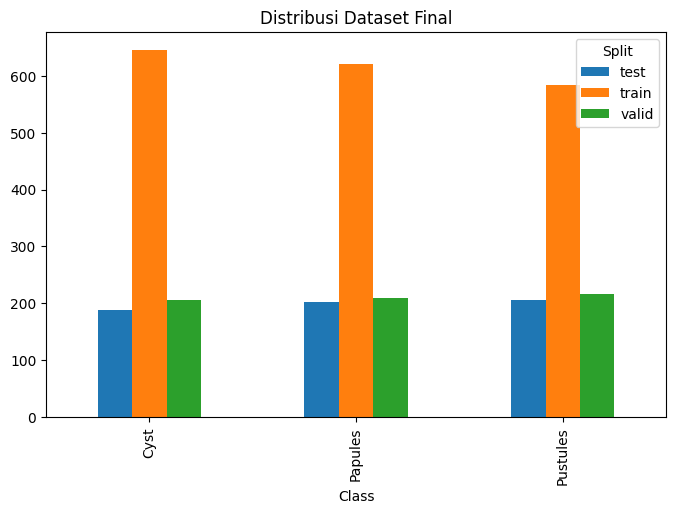

In [7]:
import matplotlib.pyplot as plt

pivot=summary.pivot(
index="Class",
columns="Split",
values="Count"
)

pivot.plot(
kind="bar",
figsize=(8,5)
)

plt.title(
"Distribusi Dataset Final"
)

plt.show()

## Analisis Distribusi Kelas

Visualisasi menunjukkan distribusi jumlah gambar pada setiap kelas jerawat yang digunakan dalam proses training.

Hasil menunjukkan bahwa distribusi data relatif seimbang:
- Cyst: 645 gambar
- Papules: 621 gambar
- Pustules: 584 gambar

Tidak ditemukan perbedaan jumlah data yang terlalu ekstrem antar kelas.

### Kesimpulan

Distribusi kelas yang cukup seimbang membantu mengurangi risiko bias model terhadap kelas tertentu dan mendukung proses pelatihan yang lebih stabil.

In [8]:
import cv2
import os

broken=[]

for split in splits:

    for cls in classes:

        folder=os.path.join(
            target,
            split,
            cls
        )

        for img in os.listdir(folder):

            path=os.path.join(
                folder,
                img
            )

            image=cv2.imread(
                path
            )

            if image is None:

                broken.append(
                    path
                )

print(
"Broken image:",
len(
broken
)
)

Broken image: 0


In [9]:
sizes=[]

for split in splits:

    for cls in classes:

        folder=os.path.join(
            target,
            split,
            cls
        )

        for img in os.listdir(folder):

            path=os.path.join(
                folder,
                img
            )

            image=cv2.imread(
                path
            )

            h,w=image.shape[:2]

            sizes.append([
                w,
                h
            ])

import pandas as pd

sizes=pd.DataFrame(
sizes,
columns=[
"width",
"height"
]
)

sizes.describe()

,width,height
count,3078.0,3078.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


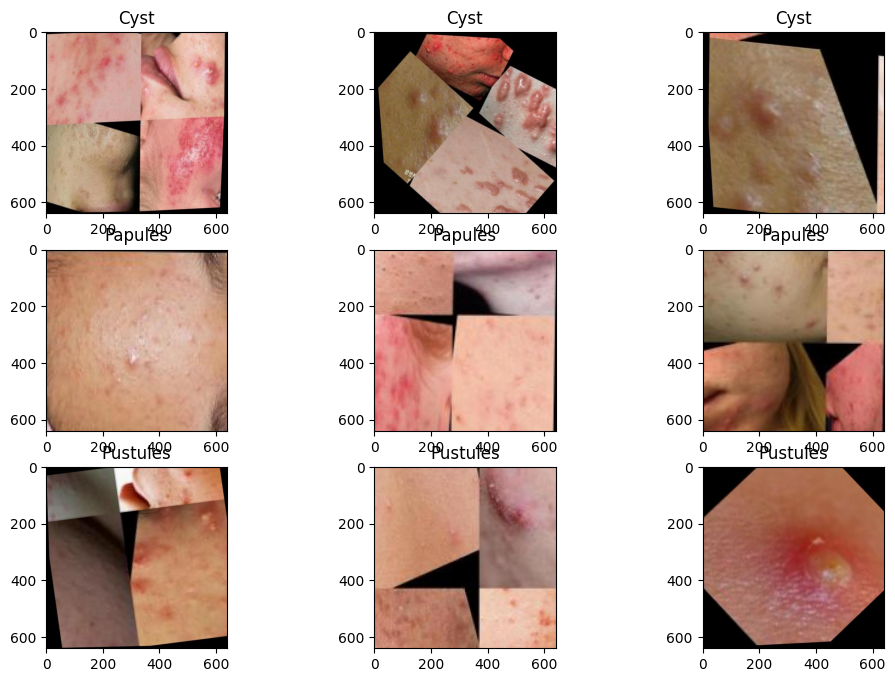

In [10]:
import random

plt.figure(
figsize=(12,8)
)

i=1

for cls in classes:

    folder=os.path.join(
        target,
        "train",
        cls
    )

    imgs=random.sample(
        os.listdir(folder),
        3
    )

    for img in imgs:

        path=os.path.join(
            folder,
            img
        )

        image=cv2.imread(
            path
        )

        image=cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(
            3,
            3,
            i
        )

        plt.imshow(
            image
        )

        plt.title(
            cls
        )

        i+=1

plt.show()

## Analisis Sampel Gambar

Visualisasi sampel dilakukan untuk memvalidasi kualitas data secara visual sebelum proses pelatihan model.

Pemeriksaan dilakukan untuk memastikan:
- gambar berhasil terbaca,
- label sesuai,
- tidak terdapat file rusak,
- dan kualitas gambar masih dapat digunakan.

Visualisasi juga membantu memastikan variasi bentuk jerawat antar kelas.

### Kesimpulan

Sampel gambar menunjukkan bahwa dataset memiliki variasi visual yang cukup baik dan layak digunakan pada tahap training model.

In [11]:
rename_map={
"Cyst":"cyst",
"Papules":"papules",
"Pustules":"pustules"
}

In [12]:
import os

base="/content/acne_final"

for split in splits:

    for old,new in rename_map.items():

        old_path=os.path.join(
            base,
            split,
            old
        )

        new_path=os.path.join(
            base,
            split,
            new
        )

        os.rename(
            old_path,
            new_path
        )

print("rename selesai")

rename selesai


In [13]:
for root,dirs,files in os.walk(
base
):

    print(
root
)

/content/acne_final
/content/acne_final/test
/content/acne_final/test/cyst
/content/acne_final/test/papules
/content/acne_final/test/pustules
/content/acne_final/valid
/content/acne_final/valid/cyst
/content/acne_final/valid/papules
/content/acne_final/valid/pustules
/content/acne_final/train
/content/acne_final/train/cyst
/content/acne_final/train/papules
/content/acne_final/train/pustules


In [14]:
!zip -r acne_final.zip acne_final

  adding: acne_final/ (stored 0%)
  adding: acne_final/test/ (stored 0%)
  adding: acne_final/test/cyst/ (stored 0%)
  adding: acne_final/test/cyst/cystic_acne_-168-_jpg.rf.ac5c9d56129072a2cc552405f31cc0e5.jpg (deflated 1%)
  adding: acne_final/test/cyst/cystic_acne_-5-_jpg.rf.be2f1e4bc64c7ec7223f2043e548a279.jpg (deflated 2%)
  adding: acne_final/test/cyst/cystic_acne_-100-_jpg.rf.f7a5d130c0fd910ed411a0a3ce4253f4.jpg (deflated 4%)
  adding: acne_final/test/cyst/cystic_acne_-43-_jpg.rf.e3fae83437c4c734dc0b669df6418120.jpg (deflated 1%)
  adding: acne_final/test/cyst/cystic_acne_-25-_jpg.rf.af2e143d32433915174a2940ee0b5e7f.jpg (deflated 2%)
  adding: acne_final/test/cyst/cystic_acne_-168-_jpg.rf.1275b746209266032c20e12aeadd1383.jpg (deflated 1%)
  adding: acne_final/test/cyst/cystic_acne_-91-_jpg.rf.1ad474504877af372a0fb0aad8fb718c.jpg (deflated 1%)
  adding: acne_final/test/cyst/cystic_acne_-136-_jpg.rf.70a944266a8c1ce2b1adb93603ac16de.jpg (deflated 3%)
  adding: acne_final/test/cyst/c

## Analisis Tahap Preprocessing

Tahap preprocessing dilakukan untuk mengoptimalkan aliran data selama proses training.

Dataset dioptimalkan menggunakan mekanisme prefetch agar proses pembacaan data dan komputasi dapat berjalan lebih efisien.

### Kesimpulan

Preprocessing berhasil meningkatkan kesiapan dataset tanpa mengubah struktur maupun label data.

In [15]:
from google.colab import files

files.download(
"acne_final.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Kesimpulan Akhir EDA Acne Dataset

Berdasarkan proses EDA dan validasi dataset yang dilakukan, dataset gambar telah memenuhi kebutuhan awal untuk pengembangan model klasifikasi jerawat.

Distribusi kelas cukup seimbang dan kualitas gambar dapat diproses dengan baik.

Dataset selanjutnya digunakan pada tahap pelatihan model CNN untuk klasifikasi Cyst, Papules, dan Pustules.